# Pronóstico a 4 semanas: ¿sirve el clima para anticipar los casos?

El notebook anterior mostró que el clima explica el *cuándo* del dengue pero casi nada del tamaño de los brotes. Una forma exigente de poner esa conclusión a prueba es pedirle al clima que **sirva para algo**: predecir cuántos casos habrá dentro de cuatro semanas. Si realmente aportara información, un modelo que lo usa debería equivocarse menos que uno que no lo conoce.

La comparación se diseña para que no pueda favorecer a ningún modelo por accidente:

- Se predice la incidencia de cada provincia **4 semanas hacia adelante**, un plazo en el que todavía se puede reaccionar.
- La validación respeta el tiempo: para predecir un año, el modelo solo ve datos de años anteriores. Nunca se mezclan semanas del futuro con las del pasado, lo que inflaría el resultado sin que se note.
- Todos los modelos se evalúan sobre exactamente las mismas filas.
- Hay **dos referencias simples** que cualquier modelo debe superar para justificarse: repetir la última semana observada y usar el promedio de esa semana en años anteriores.

Las preguntas que ordenan el recorrido:

1. ¿Qué tan difícil es superar a una referencia simple?
2. ¿Un modelo con clima pronostica mejor que uno sin clima?
3. ¿Qué variables usa realmente el modelo?

**Entradas:** `data/processed/panel_provincia_semana.csv` y `data/processed/clima_provincia_semanal.csv`.

## 1. Preparación

### 1.1 Librerías y rutas

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def encontrar_raiz(archivo=("data", "raw", "Dengue y Zika - Dic. 2019.xlsx")):
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for candidata in (base, base / "vigilancia-dengue-argentina"):
            if candidata.joinpath(*archivo).exists():
                return candidata
    raise FileNotFoundError("No se encontró data/raw/" + archivo[-1] + " desde " + str(cwd))

ROOT = encontrar_raiz()
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
IMAGES = ROOT / "images"
for carpeta in (INTERIM, PROCESSED, IMAGES):
    carpeta.mkdir(parents=True, exist_ok=True)

# Paleta del dashboard de Power BI (tema "Dengue Portfolio")
AZUL_OSCURO, ROJO, AZUL, NARANJA, VERDE, VIOLETA, AMARILLO, GRIS = (
    "#2C3E50", "#B71C1C", "#1F6FB2", "#E08E45", "#6B8E23", "#8E44AD", "#F1C40F", "#7F8C8D")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#9CA3AF", "axes.labelcolor": "#1F2937", "text.color": "#1F2937",
    "xtick.color": "#374151", "ytick.color": "#374151",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.prop_cycle": plt.cycler(color=[AZUL_OSCURO, ROJO, AZUL, NARANJA, VERDE, VIOLETA, AMARILLO, GRIS]),
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "legend.frameon": False,
})

### 1.2 Carga

In [2]:
panel = pd.read_csv(PROCESSED / "panel_provincia_semana.csv", parse_dates=["SE_inicio"])
clima = pd.read_csv(PROCESSED / "clima_provincia_semanal.csv")
clima["fecha"] = pd.to_datetime(clima["año"].astype(str) + "-W" + clima["SE"].astype(str).str.zfill(2) + "-1",
                                format="%G-W%V-%u")
print(f"Panel: {panel.shape} | clima semanal: {clima.shape}")

Panel: (8234, 12) | clima semanal: (9591, 9)


### 1.3 Calendario completo por provincia

Para crear rezagos hace falta una grilla semanal sin saltos. Se arma un calendario con todas las semanas de 2018 a 2025 para cada provincia. Donde el boletín no cubre una semana, la incidencia queda como **dato faltante** y no como cero: así, ningún rezago atraviesa una laguna sin que el modelo lo sepa. De las 9.591 semanas-provincia del calendario hay incidencia observada en 8.234.

In [3]:
# Calendario semanal completo por provincia. Donde no se observaron casos (semanas que el boletín no cubre)
# la incidencia queda como dato faltante, de modo que ningún rezago cruza una laguna sin avisar.
fechas = pd.DataFrame({"fecha": pd.date_range(clima["fecha"].min(), clima["fecha"].max(), freq="7D")})
provs = panel[["provincia", "cant_habitantes"]].drop_duplicates()

g = fechas.merge(provs, how="cross")
g = g.merge(panel[["provincia", "SE_inicio", "incidencia_100k"]].rename(columns={"SE_inicio": "fecha"}),
            on=["provincia", "fecha"], how="left")
g = g.merge(clima.drop(columns=["año", "SE", "n_estaciones"]), on=["provincia", "fecha"], how="left")
g["y"] = np.log1p(g["incidencia_100k"])             # log(1 + casos por 100.000 habitantes)
g = g.sort_values(["provincia", "fecha"]).reset_index(drop=True)
iso = g["fecha"].dt.isocalendar()
g["SE"] = iso["week"].astype(int)

print(f"Semanas x provincias: {len(g):,} | con incidencia observada: {int(g['y'].notna().sum()):,}".replace(",", "."))

Semanas x provincias: 9.591 | con incidencia observada: 8.234


### 1.4 Variables del modelo

La variable a predecir es `log(1 + incidencia)` a 4 semanas. La transformación logarítmica evita que las epidemias grandes dominen el error y permite leer las diferencias como cambios relativos. Los predictores se agrupan en tres familias:

- **Casos previos:** la incidencia de las últimas 4 semanas y su promedio.
- **Estacionalidad:** el seno y el coseno de la semana del año, que le dan al modelo una noción de época sin imponer una forma.
- **Clima:** el promedio de 4 semanas de temperatura, lluvia, humedad y días de lluvia, medido con 0, 4 y 8 semanas de rezago.

Además se agrega la provincia como variable categórica. El resultado se acota a las filas que tienen todas las variables, para que la comparación sea justa.

In [4]:
H = 4                                                 # se predice la incidencia 4 semanas hacia adelante
grp = g.groupby("provincia")

nuevas = {"target": grp["y"].shift(-H)}
for k in range(4):
    nuevas[f"y_l{k}"] = grp["y"].shift(k)
nuevas["y_m4"] = pd.concat([nuevas[f"y_l{k}"] for k in range(4)], axis=1).mean(axis=1, skipna=False)
for v in ["temp_media", "precip_mm", "hum_rel", "dias_lluvia"]:
    m4 = grp[v].transform(lambda s: s.rolling(4).mean())      # promedio de las últimas 4 semanas
    nuevas[f"{v}_m4"] = m4
    nuevas[f"{v}_m4_l4"] = m4.groupby(g["provincia"]).shift(4)
    nuevas[f"{v}_m4_l8"] = m4.groupby(g["provincia"]).shift(8)
nuevas["sen"] = np.sin(2 * np.pi * g["SE"] / 52)
nuevas["cos"] = np.cos(2 * np.pi * g["SE"] / 52)
g = pd.concat([g, pd.DataFrame(nuevas)], axis=1)

CASOS_PREVIOS = ["y_l0", "y_l1", "y_l2", "y_l3", "y_m4"]
ESTACIONAL = ["sen", "cos"]
CLIMA = [f"{v}_m4{s}" for v in ["temp_media", "precip_mm", "hum_rel", "dias_lluvia"] for s in ("", "_l4", "_l8")]

# Mismo conjunto de filas para todos los modelos: así la comparación es justa
datos = g.dropna(subset=["target"] + CASOS_PREVIOS + CLIMA).copy()
datos["fecha_objetivo"] = datos["fecha"] + pd.Timedelta(weeks=H)
datos["año_objetivo"] = datos["fecha_objetivo"].dt.isocalendar()["year"].astype(int)
datos["SE_objetivo"] = datos["fecha_objetivo"].dt.isocalendar()["week"].astype(int)
dummies = pd.get_dummies(datos["provincia"]).astype(float)
print(f"Filas de modelado: {len(datos):,}".replace(",", "."))
datos.groupby("año_objetivo").size().to_frame("filas")

Filas de modelado: 7.452


,filas
año_objetivo,
2018,276
2019,1035
2020,1219
2021,690
2022,989
2023,1081
2024,1196
2025,966


Quedan 7.452 filas de modelado, repartidas entre los años objetivo 2018 a 2025.

## 2. Validación temporal

Se evalúan cuatro años de prueba: 2022, 2023, 2024 y 2025. Para cada uno, el modelo se entrena **solo con filas cuyo objetivo cae antes de ese año**. Así, el pronóstico de 2024 usa lo aprendido hasta 2023, y nunca al revés. Los modelos de aprendizaje automático son bosques aleatorios (`RandomForestRegressor`, 300 árboles) con la misma configuración y la misma semilla.

Se comparan cinco alternativas:

| Modelo | Qué sabe |
|---|---|
| Persistencia | Repite la incidencia de la última semana observada |
| Promedio estacional | Lo que pasó en esa semana en años anteriores |
| RF solo estacionalidad y clima | Época del año y clima, sin ver casos |
| RF solo casos previos | Casos recientes y época del año |
| RF casos previos y clima | Todo lo anterior, más el clima |

In [5]:
def ajustar_rf(columnas, entrenamiento, prueba, semilla=42):
    X = pd.concat([entrenamiento[columnas], dummies.loc[entrenamiento.index]], axis=1)
    Xp = pd.concat([prueba[columnas], dummies.loc[prueba.index]], axis=1)
    modelo = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=semilla, n_jobs=-1)
    modelo.fit(X, entrenamiento["target"])
    return modelo, modelo.predict(Xp), Xp

MODELOS = {
    "RF solo estacionalidad y clima": ESTACIONAL + CLIMA,
    "RF solo casos previos": CASOS_PREVIOS + ESTACIONAL,
    "RF casos previos y clima": CASOS_PREVIOS + ESTACIONAL + CLIMA,
}
AÑOS_PRUEBA = [2022, 2023, 2024, 2025]
filas, predicciones = [], {}

for año in AÑOS_PRUEBA:
    # Entrenamiento: solo filas cuyo objetivo cae antes del año de prueba. Nada del futuro entra al modelo.
    tr = datos[datos["fecha_objetivo"] < pd.Timestamp(f"{año}-01-01")]
    te = datos[datos["año_objetivo"] == año]
    y = te["target"]

    clima_estacional = (tr.groupby(["provincia", "SE_objetivo"])["target"].mean().rename("estacional").reset_index())
    estacional = te[["provincia", "SE_objetivo"]].merge(clima_estacional, on=["provincia", "SE_objetivo"], how="left")["estacional"].fillna(0).values

    resultados = {
        "Persistencia (repetir la última semana)": te["y_l0"].values,
        "Promedio estacional de años anteriores": estacional,
    }
    for nombre, columnas in MODELOS.items():
        _, pred, _ = ajustar_rf(columnas, tr, te)
        resultados[nombre] = pred
    predicciones[año] = (te, resultados)

    for nombre, pred in resultados.items():
        filas.append({"año de prueba": año, "modelo": nombre, "filas": len(te),
                      "MAE": mean_absolute_error(y, pred), "RMSE": mean_squared_error(y, pred) ** 0.5})

metricas = pd.DataFrame(filas)
tabla_mae = metricas.pivot(index="modelo", columns="año de prueba", values="MAE")
orden = ["Persistencia (repetir la última semana)", "Promedio estacional de años anteriores"] + list(MODELOS)
tabla_mae = tabla_mae.loc[orden]
tabla_mae.round(3)

año de prueba,2022,2023,2024,2025
modelo,,,,
Persistencia (repetir la última semana),0.019,0.441,0.595,0.150
Promedio estacional de años anteriores,0.209,0.688,0.978,0.442
RF solo estacionalidad y clima,0.219,0.702,0.912,0.514
RF solo casos previos,0.026,0.357,0.399,0.162
RF casos previos y clima,0.039,0.355,0.424,0.183


La métrica es el error absoluto medio (MAE) sobre `log(1 + incidencia)`: cuanto menor, mejor. Un MAE de 0,4 en esta escala equivale a equivocarse, en promedio, por un factor de alrededor de 1,5 en la incidencia.

**Qué muestra la tabla:**

- **La persistencia es una referencia dura.** En 2025 (0,15) ningún modelo la supera. En 2022 casi no hubo casos y repetir la última semana es prácticamente perfecto (0,019).
- **Con casos previos, los modelos ganan solo cuando hay epidemia.** En 2023 el error baja de 0,44 a 0,36, y en 2024, de 0,60 a 0,40.
- **Sin ver casos, el clima no predice mejor que el calendario.** El modelo que solo conoce la estación y el clima queda al nivel del promedio estacional (2023: 0,70 contra 0,69; 2025: 0,51 contra 0,44) y muy por debajo de la persistencia.
- **Agregar clima a los casos previos no mejora nada.** El error de «casos previos y clima» empata con el de «solo casos previos» en 2023 y es mayor en los otros tres años: 0,039 contra 0,026 en 2022, 0,355 contra 0,357 en 2023, 0,424 contra 0,399 en 2024 y 0,183 contra 0,162 en 2025.

### 2.1 Error relativo a la persistencia

In [6]:
# Error de cada modelo dividido por el de la persistencia (menos de 1 = el modelo se equivoca menos que repetir la última semana)
persistencia = tabla_mae.loc["Persistencia (repetir la última semana)"]
relativo = (tabla_mae / persistencia).drop(index="Persistencia (repetir la última semana)")
relativo.round(2)

año de prueba,2022,2023,2024,2025
modelo,,,,
Promedio estacional de años anteriores,10.75,1.56,1.64,2.95
RF solo estacionalidad y clima,11.27,1.59,1.53,3.43
RF solo casos previos,1.33,0.81,0.67,1.08
RF casos previos y clima,2.00,0.80,0.71,1.22


Un valor por debajo de 1 significa que el modelo se equivoca menos que repetir la última semana. El 2022 muestra valores muy altos solo porque el error de la persistencia ese año es casi cero (no hubo casos que pronosticar), de modo que cualquier diferencia se amplifica al dividir. No indica que los modelos hayan funcionado mal.

## 3. Qué usa el modelo

La importancia por permutación mide cuánto empeora el pronóstico cuando se desordenan al azar los valores de un grupo de variables: si el modelo las usa, el error sube mucho; si las ignora, casi no cambia. Se calcula sobre 2024, el año más exigente.

In [7]:
# Importancia por permutación en el año más exigente (2024): cuánto sube el error al desordenar cada grupo de variables
año = 2024
tr = datos[datos["fecha_objetivo"] < pd.Timestamp(f"{año}-01-01")]
te = datos[datos["año_objetivo"] == año]
modelo, pred, Xp = ajustar_rf(MODELOS["RF casos previos y clima"], tr, te)
base_mae = mean_absolute_error(te["target"], pred)

grupos = {"casos previos": CASOS_PREVIOS, "estacionalidad": ESTACIONAL, "clima": CLIMA, "provincia": list(dummies.columns)}
rng = np.random.default_rng(0)
aumento = {}
for nombre, cols in grupos.items():
    veces = []
    for _ in range(10):
        X2 = Xp.copy()
        X2[cols] = X2[cols].values[rng.permutation(len(X2))]
        veces.append(mean_absolute_error(te["target"], modelo.predict(X2)) - base_mae)
    aumento[nombre] = np.mean(veces)
importancia = pd.Series(aumento).sort_values(ascending=False)
importancia.round(3).to_frame("aumento del MAE")

,aumento del MAE
casos previos,0.984
estacionalidad,0.205
clima,0.069
provincia,0.003


El modelo se apoya casi por completo en los **casos previos** (el error sube 0,98 al desordenarlos), bastante menos en la estacionalidad (0,20) y muy poco en el clima (0,07). La provincia casi no importa (0,003). El clima entra en el modelo, pero lo que aporta no mejora el pronóstico fuera de la muestra: es la señal que ya está contenida en el calendario y en los casos recientes.

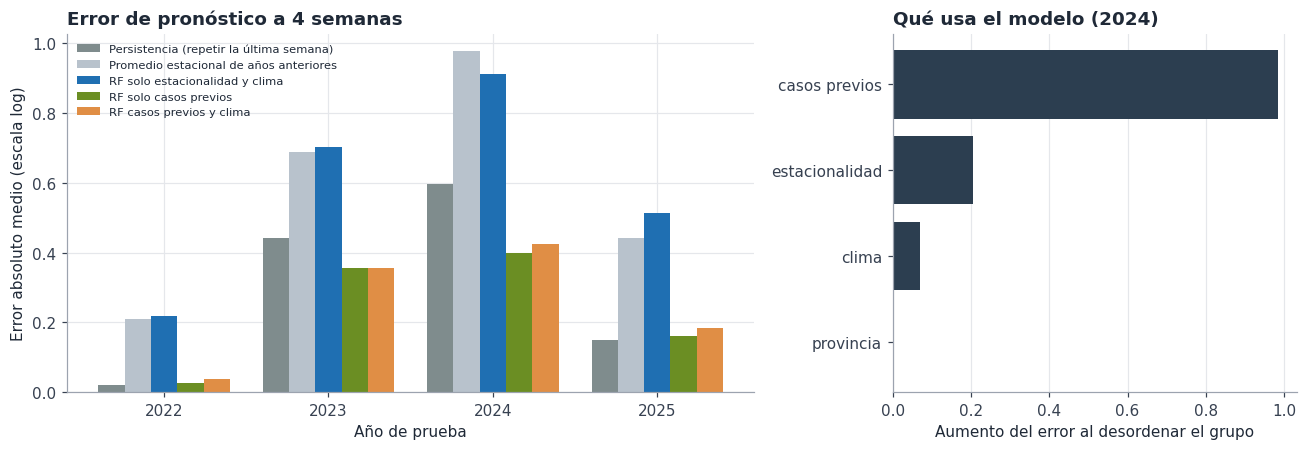

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.7, 1]})
ax = axes[0]
paleta = [GRIS, "#B8C2CC", AZUL, VERDE, NARANJA]
ancho = 0.16
for i, (modelo_n, fila) in enumerate(tabla_mae.iterrows()):
    ax.bar(np.arange(len(fila)) + (i - 2) * ancho, fila.values, ancho, label=modelo_n, color=paleta[i])
ax.set_xticks(range(len(AÑOS_PRUEBA)), [str(a) for a in AÑOS_PRUEBA])
ax.set_xlabel("Año de prueba")
ax.set_ylabel("Error absoluto medio (escala log)")
ax.set_title("Error de pronóstico a 4 semanas")
ax.legend(fontsize=7.5, loc="upper left")

axes[1].barh(importancia.index[::-1], importancia.values[::-1], color=AZUL_OSCURO)
axes[1].set_xlabel("Aumento del error al desordenar el grupo")
axes[1].set_title("Qué usa el modelo (2024)")
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
fig.savefig(IMAGES / "analisis-modelos.png")
plt.show()

## 4. Un ejemplo concreto

Las tres provincias con más casos en 2024, con el valor observado, la persistencia y el modelo con casos previos y clima.

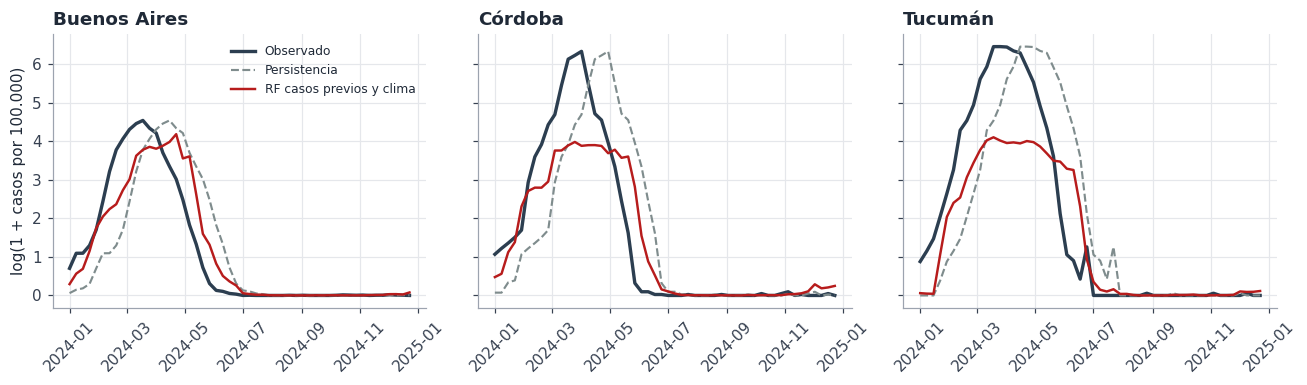

In [9]:
# Un caso concreto: las tres provincias con más casos en 2024
te, resultados = predicciones[2024]
top3 = panel[panel["año"] == 2024].groupby("provincia")["cant_casos"].sum().nlargest(3).index
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, prov in zip(axes, top3):
    m = (te["provincia"] == prov).values
    f = te.loc[m, "fecha_objetivo"]
    ax.plot(f, te.loc[m, "target"], color=AZUL_OSCURO, lw=2.2, label="Observado")
    ax.plot(f, resultados["Persistencia (repetir la última semana)"][m], color=GRIS, lw=1.4, ls="--", label="Persistencia")
    ax.plot(f, resultados["RF casos previos y clima"][m], color=ROJO, lw=1.6, label="RF casos previos y clima")
    ax.set_title(prov)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("log(1 + casos por 100.000)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

El modelo sigue la forma general de la curva y reduce el desfase de la persistencia (que, por construcción, es la curva observada corrida cuatro semanas). Pero **subestima los picos**: en Tucumán el máximo pronosticado es 4,1 contra 6,5 observado, y en Córdoba 4,0 contra 6,3, en la escala logarítmica. Además, lo que le da información son los casos previos, de modo que sube cuando los casos ya empezaron a crecer. No anticipa el inicio de un brote, y esa es la parte que más valdría anticipar.

## 5. Conclusiones

1. **Los casos recientes son, por lejos, el mejor predictor** a 4 semanas. Un modelo que los usa mejora a la persistencia en las dos temporadas epidémicas evaluadas (2023 y 2024).
2. **El clima no mejora el pronóstico.** Agregarlo a los casos previos deja el error igual en 2023 y algo peor en los otros tres años de prueba, y sin casos previos el clima no supera al promedio estacional.
3. **Esto confirma, con otro método, la conclusión del notebook 04:** el clima marca la estación en que ocurre el dengue, pero no permite anticipar cuándo empieza un brote ni qué tan grande será.

**Limitaciones que hay que tener presentes**

- Hay pocas temporadas epidémicas (tres en ocho años), de modo que las diferencias entre modelos con errores parecidos, como 0,355 y 0,357 en 2023, no son distinguibles del azar.
- Los bosques aleatorios no extrapolan: el brote de 2024 fue mucho mayor que todos los anteriores, y ningún bosque puede predecir valores por encima de los que vio al entrenar.
- El clima de cada provincia es el promedio de sus estaciones del SMN, un resumen grueso de condiciones que varían dentro de cada provincia.
- Los modelos usan solo clima y casos. Si el tamaño de un brote depende de la inmunidad previa de la población, del serotipo circulante o de la presencia del vector, esos factores no están en los datos y por eso no pueden aparecer en el resultado.

Un resultado negativo bien documentado vale más que una correlación vistosa que no resiste una validación temporal. Lo que sí se puede hacer con estos datos es describir con claridad cómo se comportó el dengue y en qué estación ocurre, y esa es la base del dashboard.